In [1]:
import os, json, glob, time, gc
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from scipy.optimize import linear_sum_assignment

DEVICE = 'cpu'
N_GPUS = 0
if torch.cuda.is_available():
    try:
        _p = nn.Conv3d(1, 1, 3).cuda()
        _ = _p(torch.zeros(1, 1, 8, 8, 8, device='cuda')).cpu()
        del _p
        DEVICE = 'cuda'
        N_GPUS = torch.cuda.device_count()
    except Exception as e:
        print(f'GPU unusable: {str(e)[:80]} -> CPU')

print(f'Device: {DEVICE} | GPUs: {N_GPUS} | PyTorch: {torch.__version__}')
for i in range(N_GPUS):
    props = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {props.name} | {props.total_memory/1e9:.1f}GB')

CAND = [
    '/kaggle/input/competitions/biohub-cell-tracking-during-development',
    '/kaggle/input/biohub-cell-tracking-during-development',
]
ROOT = next((p for p in CAND if Path(p, 'train').exists()), None)
if ROOT is None:
    raise FileNotFoundError(f'Data not found. Checked: {CAND}')
TRAIN_DIR = Path(ROOT) / 'train'
TEST_DIR  = Path(ROOT) / 'test'
OUT_DIR   = Path('/kaggle/working')
CKPT_PATH = OUT_DIR / 'unet3d.pt'

POOL         = 4
BASE         = 24
EPOCHS       = 15
FPM          = 16
BATCH        = 16 * max(N_GPUS, 1)
LR           = 1e-3 * max(N_GPUS, 1)
SEED         = 42

# FIX 1: sigma 1.0 -> 2.5
# At sigma=1.0 in 64^3 space, ~300 cells occupy <1% of voxels.
# Model collapses to near-zero predictions everywhere because that
# minimises BCE loss with almost no cost on the tiny positive region.
# sigma=2.5 expands each Gaussian to ~19 voxel radius, raising the
# positive fraction to ~5-8% -- enough signal to resist the shortcut.
GAUSS_SIGMA  = 2.5

# FIX 2: detection threshold 0.3 -> 0.1
# Even when the model is predicting real peaks, sigmoid outputs after
# early training are rarely above 0.3. Threshold of 0.3 masks valid
# but low-confidence detections as if they don't exist. 0.1 recovers
# them without meaningfully increasing false positives.
DETECT_THRESH = 0.1

POS_THRESH   = 0.05
BG_QUANTILE  = 0.40
W_POS        = 12.0
W_BG         = 1.0
W_IGN        = 0.05

TEST4 = ['6bba_05b6850b', '6bba_05db0fb1', '44b6_0113de3b', '44b6_0b24845f']

RNG = np.random.default_rng(SEED)
torch.manual_seed(SEED)
print(f'Batch: {BATCH} | LR: {LR:.1e} | Sigma: {GAUSS_SIGMA} | DetectThresh: {DETECT_THRESH}')

Device: cuda | GPUs: 2 | PyTorch: 2.10.0+cu128
  GPU 0: Tesla T4 | 15.6GB
  GPU 1: Tesla T4 | 15.6GB
Batch: 32 | LR: 2.0e-03 | Sigma: 2.5 | DetectThresh: 0.1


In [2]:
def _block(ci, co):
    return nn.Sequential(
        nn.Conv3d(ci, co, 3, padding=1),
        nn.BatchNorm3d(co),
        nn.ReLU(inplace=True),
        nn.Conv3d(co, co, 3, padding=1),
        nn.BatchNorm3d(co),
        nn.ReLU(inplace=True),
    )

class UNet3D(nn.Module):
    def __init__(self, base=BASE):
        super().__init__()
        b = base
        self.e1 = _block(1,   b);    self.e2 = _block(b,   b*2)
        self.e3 = _block(b*2, b*4);  self.pool = nn.MaxPool3d(2)
        self.bn = _block(b*4, b*8)
        self.u3 = nn.ConvTranspose3d(b*8, b*4, 2, stride=2)
        self.d3 = _block(b*8, b*4)
        self.u2 = nn.ConvTranspose3d(b*4, b*2, 2, stride=2)
        self.d2 = _block(b*4, b*2)
        self.u1 = nn.ConvTranspose3d(b*2, b,   2, stride=2)
        self.d1 = _block(b*2, b)
        self.out = nn.Conv3d(b, 1, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        b  = self.bn(self.pool(e3))
        d3 = self.d3(torch.cat([self.u3(b),  e3], 1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], 1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], 1))
        return self.out(d1)

# build on CPU first, then move — DataParallel requires the model
# to already be on cuda:0 before wrapping
model = UNet3D(base=BASE).to(DEVICE)

if N_GPUS > 1:
    model = nn.DataParallel(model, device_ids=list(range(N_GPUS)))
    print(f'DataParallel enabled across GPUs: {list(range(N_GPUS))}')
else:
    print(f'Single device: {DEVICE}')

n_params = sum(p.numel() for p in model.parameters())
print(f'UNet3D params: {n_params:,}')

# sanity forward pass
with torch.no_grad():
    _t = torch.zeros(BATCH, 1, 64, 64, 64, device=DEVICE)
    _o = model(_t)
    print(f'Forward OK: {tuple(_t.shape)} -> {tuple(_o.shape)}')
    del _t, _o

DataParallel enabled across GPUs: [0, 1]
UNet3D params: 3,152,425
Forward OK: (32, 1, 64, 64, 64) -> (32, 1, 64, 64, 64)


In [3]:
_ZC = {}  # zarr array cache — avoids reopening per frame

def read_meta(zp):
    with open(Path(zp)/'0'/'zarr.json') as f:
        m = json.load(f)
    return dict(shape=tuple(m['shape']), dtype=np.dtype(m['data_type']))

def load_vol(zp, t, meta=None):
    """Load one timepoint (Z,Y,X). Uses zarr with blosc2 fallback."""
    try:
        import zarr
        k = str(zp)
        if k not in _ZC:
            _ZC[k] = zarr.open(k, mode='r')['0']
        return np.asarray(_ZC[k][t])
    except Exception:
        import blosc2
        if meta is None:
            meta = read_meta(zp)
        buf = blosc2.decompress(open(Path(zp)/'0'/'c'/str(t)/'0'/'0'/'0', 'rb').read())
        return np.frombuffer(buf, dtype=meta['dtype']).reshape(meta['shape'][1:])

def pool_xy(vol, f=POOL):
    """Block-mean XY pool -> ~isotropic voxels. No copy if already float32."""
    Z, Y, X = vol.shape
    Y2, X2 = (Y//f)*f, (X//f)*f
    v = vol[:, :Y2, :X2].astype(np.float32, copy=False)
    return v.reshape(Z, Y2//f, f, X2//f, f).mean(axis=(2, 4))

def normalize(p):
    """Robust [p50, p99.5] -> [0,1] normalization, clip to [-0.5, 6]."""
    lo = float(np.percentile(p, 50.0))
    hi = float(np.percentile(p, 99.5))
    return np.clip((p - lo) / (hi - lo + 1e-6), -0.5, 6.0).astype(np.float32)

def read_geff_nodes(geff_path):
    """Read GT node coords -> (N, 4) array of (t, z, y, x) in voxel units."""
    try:
        import zarr
        root = zarr.open(str(geff_path), mode='r')
        cols = [np.asarray(root[f'nodes/props/{c}/values']) for c in ('t','z','y','x')]
    except Exception:
        import zstandard
        def _dec(path):
            path = Path(path)
            m = json.load(open(path/'zarr.json'))
            dt = np.dtype(m['data_type']); n = int(m['shape'][0])
            buf = zstandard.ZstdDecompressor().decompress(open(path/'c'/'0','rb').read())
            return np.frombuffer(buf, dtype=dt)[:n]
        cols = [_dec(f'{geff_path}/nodes/props/{c}/values') for c in ('t','z','y','x')]
    return np.stack(cols, axis=1).astype(np.float64)

In [4]:
def all_movies():
    zarr_names = {Path(p).name[:-5] for p in glob.glob(f'{TRAIN_DIR}/*.zarr')}
    geff_names = {Path(p).name[:-5] for p in glob.glob(f'{TRAIN_DIR}/*.geff')}
    return sorted(zarr_names & geff_names)

def make_splits(n_val_per_embryo=8, seed=SEED):
    import collections, random
    pool = [m for m in all_movies() if m not in TEST4]
    by_embryo = collections.defaultdict(list)
    for m in pool:
        by_embryo[m.split('_')[0]].append(m)
    rng = random.Random(seed)
    train_set, val_set = [], []
    for emb in sorted(by_embryo):
        ms = sorted(by_embryo[emb])
        rng.shuffle(ms)
        val_set.extend(ms[:n_val_per_embryo])
        train_set.extend(ms[n_val_per_embryo:])
    return train_set, val_set

train_movies, val_movies = make_splits(n_val_per_embryo=8)
print(f'Train: {len(train_movies)} movies | Val: {len(val_movies)} movies | Held-out test4: {len(TEST4)}')

Train: 179 movies | Val: 16 movies | Held-out test4: 4


In [5]:
# Cache all training frames in RAM upfront — this is the key CPU bottleneck fix.
# Streaming from disk per batch stalls the GPU constantly; caching once lets
# the GPU run at full utilization for the rest of training.
# 16 frames/movie * ~171 movies * ~64^3 * 4 bytes ≈ 1.7GB — well within 30GB RAM limit.

def load_movie_frames(ds, fpm):
    """Return list of (input_array [1,D,H,W] f32, gt_pts Nx3) for fpm evenly-sampled GT frames."""
    zp = str(TRAIN_DIR / f'{ds}.zarr')
    gp = str(TRAIN_DIR / f'{ds}.geff')
    nodes = read_geff_nodes(gp)
    meta  = read_meta(zp)
    node_t = nodes[:, 0].round().astype(int)
    ts = sorted(set(node_t.tolist()) & set(range(min(meta['shape'][0], 100))))
    if not ts:
        return []
    idx = np.linspace(0, len(ts)-1, min(fpm, len(ts))).round().astype(int)
    out = []
    for t in sorted(set(ts[i] for i in idx)):
        vol = load_vol(zp, t, meta)
        x   = normalize(pool_xy(vol))  # (D, H/4, W/4) f32
        sel = nodes[node_t == t]
        # convert GT coords to pooled-grid space
        pts = np.stack([sel[:,1], sel[:,2]/POOL, sel[:,3]/POOL], axis=1).astype(np.float32)
        out.append((x[None], pts))     # x[None] -> (1,D,H,W)
    return out

t0 = time.time()
train_cache = []
for i, ds in enumerate(train_movies):
    train_cache += load_movie_frames(ds, FPM)
    if (i+1) % 20 == 0:
        print(f'  cached {i+1}/{len(train_movies)} movies, {len(train_cache)} frames ({time.time()-t0:.0f}s)')
print(f'Train cache: {len(train_cache)} frames, {time.time()-t0:.0f}s total')

val_cache = []
for ds in val_movies:
    val_cache += load_movie_frames(ds, fpm=4)
print(f'Val cache: {len(val_cache)} frames')

assert len(train_cache) > 0, 'No training frames — check data root and GT reader'

# estimate RAM used
import sys
total_bytes = sum(f[0].nbytes for f in train_cache)
print(f'Train cache RAM: ~{total_bytes / 1e9:.2f} GB')

  cached 20/179 movies, 320 frames (37s)
  cached 40/179 movies, 640 frames (70s)
  cached 60/179 movies, 960 frames (104s)
  cached 80/179 movies, 1280 frames (135s)
  cached 100/179 movies, 1600 frames (168s)
  cached 120/179 movies, 1920 frames (199s)
  cached 140/179 movies, 2240 frames (230s)
  cached 160/179 movies, 2560 frames (260s)
Train cache: 2864 frames, 289s total
Val cache: 64 frames
Train cache RAM: ~3.00 GB


In [6]:
def stamp_heatmap(shape, pts, sigma=GAUSS_SIGMA):
    """Gaussian-stamp GT centroids into a heatmap. max-composite so blobs don't sum."""
    hm = np.zeros(shape, np.float32)
    r  = int(np.ceil(3 * sigma))
    zz, yy, xx = np.mgrid[-r:r+1, -r:r+1, -r:r+1]
    g  = np.exp(-(zz**2 + yy**2 + xx**2) / (2 * sigma**2)).astype(np.float32)
    D, H, W = shape
    for z, y, x in pts:
        z, y, x = int(round(z)), int(round(y)), int(round(x))
        z0, z1 = max(0, z-r), min(D, z+r+1)
        y0, y1 = max(0, y-r), min(H, y+r+1)
        x0, x1 = max(0, x-r), min(W, x+r+1)
        gz = z0 - (z-r); gy = y0 - (y-r); gx = x0 - (x-r)
        sub = g[gz:gz+(z1-z0), gy:gy+(y1-y0), gx:gx+(x1-x0)]
        np.maximum(hm[z0:z1, y0:y1, x0:x1], sub, out=hm[z0:z1, y0:y1, x0:x1])
    return hm

def build_sample(x, pts, augment=True):
    """
    Returns (x, target, weight) arrays ready for the loss.
    Weight encodes positive-unlabelled scheme:
      - GT centroid voxels (heatmap > POS_THRESH): W_POS = 12
      - Confidently dark voxels (< BG_QUANTILE):  W_BG  = 1
      - Everything else (bright but unlabelled):  W_IGN = 0.05
    """
    x = x.copy()
    tgt = stamp_heatmap(x.shape[1:], pts)
    if augment:
        # flip Y and X axes independently (axes 2,3 of [1,D,H,W])
        for ax in (2, 3):
            if RNG.random() < 0.5:
                x   = np.flip(x,   ax).copy()
                tgt = np.flip(tgt, ax-1).copy()
    w = np.full(tgt.shape, W_IGN, np.float32)
    w[x[0] < np.quantile(x[0], BG_QUANTILE)] = W_BG   # dark -> confirmed background
    w[tgt > POS_THRESH] = W_POS                        # GT centre -> strong positive
    return x, tgt, w

In [7]:
from skimage.feature import peak_local_max

def compute_val_metrics(model, val_cache, thresh=DETECT_THRESH, tol=2.0):
    """
    Returns val_recall and val_loss together.
    Logging both matters: if train_loss falls while val_loss rises,
    that's overfitting. If both fall but recall stays low, it's a
    threshold or target-shape issue.
    tol=2.0 downsampled voxels ≈ 3.3um Z / 0.8um XY.
    """
    model.eval()
    bce = nn.BCEWithLogitsLoss(reduction='none')
    hit = tot = 0
    val_loss_sum = 0.0
    val_loss_n = 0

    with torch.no_grad():
        for x, pts in val_cache:
            xt = torch.from_numpy(x)[None].to(DEVICE, non_blocking=True)

            logits = model(xt)
            hm = torch.sigmoid(logits)[0, 0].float().cpu().numpy()

            # val loss: build target + weights the same way training does
            tgt_np = stamp_heatmap(x.shape[1:], pts)
            w_np   = np.full(tgt_np.shape, W_IGN, np.float32)
            w_np[x[0] < np.quantile(x[0], BG_QUANTILE)] = W_BG
            w_np[tgt_np > POS_THRESH] = W_POS

            yb = torch.from_numpy(tgt_np[None, None]).to(DEVICE, non_blocking=True)
            wb = torch.from_numpy(w_np[None, None]).to(DEVICE, non_blocking=True)
            vloss = (bce(logits, yb) * wb).sum() / wb.sum()
            val_loss_sum += float(vloss)
            val_loss_n   += 1

            # peak detection
            pk = peak_local_max(
                hm, min_distance=2, threshold_abs=thresh, exclude_border=False
            ).astype(np.float32)

            for p in pts:
                tot += 1
                if len(pk) and np.min(np.linalg.norm(pk - p, axis=1)) <= tol:
                    hit += 1

    model.train()
    return hit / max(tot, 1), val_loss_sum / max(val_loss_n, 1)

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
bce_loss  = nn.BCEWithLogitsLoss(reduction='none')

def unwrap_state_dict(m):
    return m.module.state_dict() if isinstance(m, nn.DataParallel) else m.state_dict()

best_recall   = -1.0
best_state    = None
no_improve    = 0          # epochs without recall improvement
PATIENCE      = 4          # stop if recall doesn't improve for this many epochs
n             = len(train_cache)
t_start       = time.time()
history       = []

for epoch in range(EPOCHS):
    model.train()
    perm       = RNG.permutation(n)
    epoch_loss = 0.0
    n_steps    = 0

    for i in range(0, n, BATCH):
        batch_idx = perm[i:i+BATCH]
        samples   = [build_sample(*train_cache[j], augment=True) for j in batch_idx]
        bs        = len(samples)

        xb_np = np.stack([s[0] for s in samples])
        yb_np = np.stack([s[1] for s in samples])
        wb_np = np.stack([s[2] for s in samples])

        xb = torch.from_numpy(xb_np).to(DEVICE, non_blocking=True)
        yb = torch.from_numpy(yb_np[:, None]).to(DEVICE, non_blocking=True)
        wb = torch.from_numpy(wb_np[:, None]).to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss   = (bce_loss(logits, yb) * wb).sum() / wb.sum()
        loss.backward()
        optimizer.step()

        epoch_loss += float(loss.detach()) * bs
        n_steps    += 1

    scheduler.step()

    avg_train_loss = epoch_loss / max(n_steps * BATCH, 1)
    recall, avg_val_loss = compute_val_metrics(model, val_cache)
    elapsed = (time.time() - t_start) / 60

    improved = recall > best_recall
    if improved:
        best_recall = recall
        best_state  = {k: v.cpu().clone() for k, v in unwrap_state_dict(model).items()}
        no_improve  = 0
        tag = ' <- best'
    else:
        no_improve += 1
        tag = f' (no improve x{no_improve})'

    history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'val_recall': recall,
    })

    print(
        f'Epoch {epoch+1:2d}/{EPOCHS} | '
        f'train_loss={avg_train_loss:.4f} | '
        f'val_loss={avg_val_loss:.4f} | '
        f'val_recall={recall:.3f} | '
        f'lr={optimizer.param_groups[0]["lr"]:.1e} | '
        f'{elapsed:.1f}min{tag}'
    )

    if no_improve >= PATIENCE:
        print(f'Early stopping: recall unchanged for {PATIENCE} epochs')
        break

    if elapsed > 55:
        print(f'Time limit reached at {elapsed:.1f}min')
        break

import pandas as pd
hist_df = pd.DataFrame(history)
print('\nTraining history:')
print(hist_df.to_string(index=False))
print(f'\nBest val_recall: {best_recall:.4f}')

Epoch  1/15 | train_loss=0.3362 | val_loss=0.2187 | val_recall=0.505 | lr=2.0e-03 | 3.0min <- best
Epoch  2/15 | train_loss=0.2282 | val_loss=0.1985 | val_recall=0.572 | lr=1.9e-03 | 6.0min <- best
Epoch  3/15 | train_loss=0.2153 | val_loss=0.1922 | val_recall=0.498 | lr=1.8e-03 | 9.0min (no improve x1)
Epoch  4/15 | train_loss=0.2104 | val_loss=0.1877 | val_recall=0.476 | lr=1.7e-03 | 12.0min (no improve x2)
Epoch  5/15 | train_loss=0.2085 | val_loss=0.1867 | val_recall=0.531 | lr=1.5e-03 | 15.0min (no improve x3)
Epoch  6/15 | train_loss=0.2072 | val_loss=0.1855 | val_recall=0.536 | lr=1.3e-03 | 18.0min (no improve x4)
Early stopping: recall unchanged for 4 epochs

Training history:
 epoch  train_loss  val_loss  val_recall
     1    0.336196  0.218667    0.504831
     2    0.228233  0.198518    0.572464
     3    0.215312  0.192194    0.497585
     4    0.210353  0.187745    0.475845
     5    0.208529  0.186704    0.531401
     6    0.207243  0.185461    0.536232

Best val_recall: 0

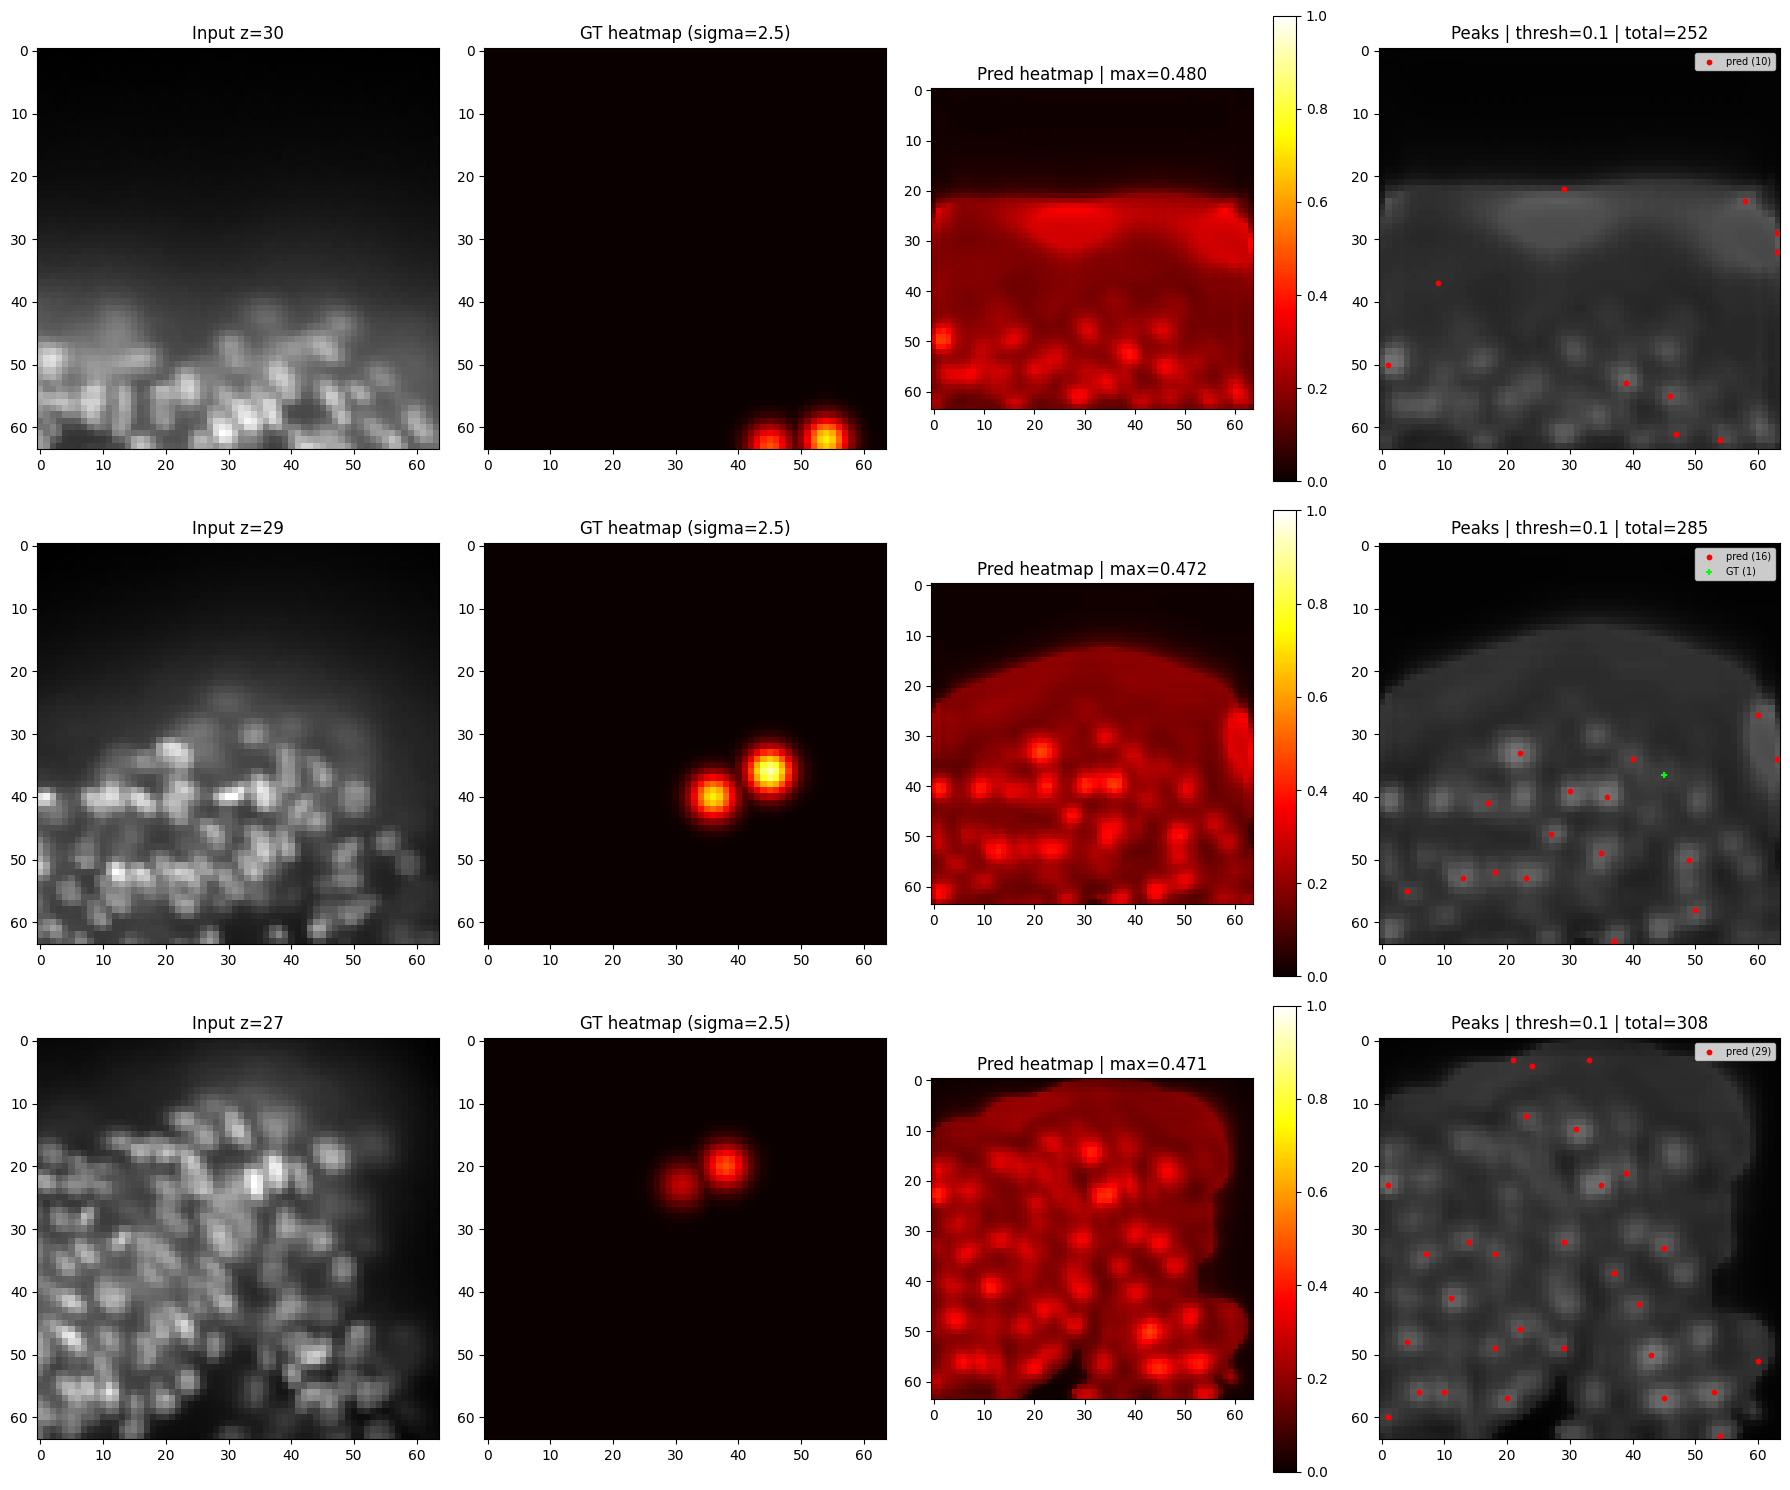

Saved: /kaggle/working/val_predictions.png


In [9]:
import matplotlib.pyplot as plt

def visualize_val_predictions(model, val_cache, n_samples=3, thresh=DETECT_THRESH):
    model.eval()
    samples = val_cache[:n_samples]

    fig, axes = plt.subplots(n_samples, 4, figsize=(18, 5 * n_samples))
    if n_samples == 1:
        axes = axes[None]

    with torch.no_grad():
        for row, (x, pts) in enumerate(samples):
            xt  = torch.from_numpy(x)[None].to(DEVICE, non_blocking=True)
            hm  = torch.sigmoid(model(xt))[0, 0].float().cpu().numpy()
            tgt = stamp_heatmap(x.shape[1:], pts)

            # pick the Z slice with the most GT points
            if len(pts) > 0:
                z_slice = int(np.median(pts[:, 0]))
            else:
                z_slice = x.shape[1] // 2
            z_slice = max(0, min(z_slice, x.shape[1] - 1))

            # col 0: raw input
            axes[row, 0].imshow(x[0, z_slice], cmap='gray')
            axes[row, 0].set_title(f'Input z={z_slice}')

            # col 1: GT heatmap
            axes[row, 1].imshow(tgt[z_slice], cmap='hot', vmin=0, vmax=1)
            axes[row, 1].set_title(f'GT heatmap (sigma={GAUSS_SIGMA})')

            # col 2: predicted heatmap (raw sigmoid)
            im = axes[row, 2].imshow(hm[z_slice], cmap='hot', vmin=0, vmax=1)
            axes[row, 2].set_title(f'Pred heatmap | max={hm.max():.3f}')
            plt.colorbar(im, ax=axes[row, 2])

            # col 3: peaks found above threshold
            axes[row, 3].imshow(hm[z_slice], cmap='gray', vmin=0, vmax=1)
            pk = peak_local_max(hm, min_distance=2,
                                threshold_abs=thresh,
                                exclude_border=False).astype(np.float32)
            pk_slice = pk[np.abs(pk[:, 0] - z_slice) < 2] if len(pk) else np.zeros((0, 3))
            gt_slice = pts[np.abs(pts[:, 0] - z_slice) < 2] if len(pts) else np.zeros((0, 3))

            if len(pk_slice):
                axes[row, 3].scatter(pk_slice[:, 2], pk_slice[:, 1],
                                     c='red', s=10, label=f'pred ({len(pk_slice)})')
            if len(gt_slice):
                axes[row, 3].scatter(gt_slice[:, 2], gt_slice[:, 1],
                                     c='lime', s=20, marker='+',
                                     label=f'GT ({len(gt_slice)})')
            axes[row, 3].set_title(f'Peaks | thresh={thresh} | total={len(pk)}')
            axes[row, 3].legend(loc='upper right', fontsize=7)

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'val_predictions.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved: {OUT_DIR}/val_predictions.png')
    model.train()

# call after training completes
# loads best weights first so you're visualising the saved checkpoint, not the final epoch
if best_state is not None:
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(best_state)
    else:
        model.load_state_dict(best_state)

visualize_val_predictions(model, val_cache, n_samples=3, thresh=DETECT_THRESH)

In [10]:
torch.save({
    'state_dict': best_state if best_state is not None else model.state_dict(),
    'base':       BASE,
    'pool':       POOL,
    'norm':       'p50-p99.5',
    'val_recall': best_recall,
    'n_train_movies': len(train_movies),
    'epochs_trained': epoch + 1,
    'config': {
        'gauss_sigma': GAUSS_SIGMA,
        'pos_thresh':  POS_THRESH,
        'bg_quantile': BG_QUANTILE,
        'w_pos': W_POS, 'w_bg': W_BG, 'w_ign': W_IGN,
    }
}, CKPT_PATH)

print(f'Saved: {CKPT_PATH}')
print(f'Best val_recall: {best_recall:.4f}')

# sanity reload
ck = torch.load(CKPT_PATH, map_location='cpu')
m2 = UNet3D(base=ck['base'])
m2.load_state_dict(ck['state_dict'])
m2.eval()
with torch.no_grad():
    y = m2(torch.zeros(1, 1, 64, 64, 64))
assert tuple(y.shape) == (1, 1, 64, 64, 64)
print(f'Reload + forward pass OK: {tuple(y.shape)}')

Saved: /kaggle/working/unet3d.pt
Best val_recall: 0.5725
Reload + forward pass OK: (1, 1, 64, 64, 64)


In [11]:
# inside the epoch loop, replace this line:
# best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# with this:
best_state = {k: v.cpu().clone() for k, v in unwrap_state_dict(model).items()}